In [1]:
from google.colab import drive
drive.mount('/content/drive')

!pip install transformers torch -q

import pandas as pd
import numpy as np
import os

BASE = '/content/drive/MyDrive/edtech_absa'

# Load your aspect-tagged sentences
df = pd.read_csv(f'{BASE}/data/processed/reviews_with_aspects.csv')

# Filter out General — they have no aspect so can't contribute to scores
df = df[df['aspect'] != 'General'].copy()
df = df.reset_index(drop=True)

print(f"Sentences with valid aspects: {len(df)}")
print(df['aspect'].value_counts())
print(f"\nPlatforms: {df['platform'].unique()}")

Mounted at /content/drive
Sentences with valid aspects: 35409
aspect
Platform_UX        17644
Support             4869
Content_Quality     4750
Pricing             4065
Instructor          1947
Certification       1425
Community            709
Name: count, dtype: int64

Platforms: ['Coursera' 'Udemy' 'LinkedIn_Learning' 'edX' 'Pluralsight']


In [2]:
from transformers import pipeline
import torch

print("GPU available:", torch.cuda.is_available())

# This model is specifically trained for sentiment analysis
# Much smaller than BART — loads in 30 seconds
sentiment_model = pipeline(
    'sentiment-analysis',
    model='cardiffnlp/twitter-roberta-base-sentiment-latest',
    device=0,          # GPU
    max_length=128,
    truncation=True
)

# Test it on a sample sentence
test = sentiment_model("The course content is absolutely excellent and very detailed")
print("Test result:", test)
# Should show: [{'label': 'positive', 'score': 0.98...}]

GPU available: True


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/501M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

...

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/501M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Test result: [{'label': 'positive', 'score': 0.9834485054016113}]


In [3]:
from tqdm import tqdm

print(f"Scoring {len(df)} sentences for sentiment...")
print("Estimated time: 5–8 minutes on T4\n")

def get_sentiment_score(texts, batch_size=64):
    """
    Returns a score from 0 to 10 for each sentence.
    Positive → high score, Negative → low score, Neutral → 5.0
    """
    all_scores = []

    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        results = sentiment_model(batch)

        for res in results:
            label = res['label'].lower()
            conf  = res['score']  # model confidence 0–1

            # Convert to 0–10 scale
            if 'positive' in label:
                score = 5 + (conf * 5)    # 5.0 → 10.0
            elif 'negative' in label:
                score = 5 - (conf * 5)    # 0.0 → 5.0
            else:
                score = 5.0               # neutral stays at 5

            all_scores.append(round(score, 3))

        if (i // batch_size) % 20 == 0 and i > 0:
            print(f"  {i}/{len(texts)} sentences scored...")

    return all_scores

sentences_list = df['sentence'].tolist()
df['sentiment_score'] = get_sentiment_score(sentences_list)
df['sentiment_raw']   = [
    r['label'].lower()
    for r in sentiment_model(sentences_list[:5])  # just for reference
]

print("\nSentiment scoring complete!")
print(df['sentiment_score'].describe().round(3))

Scoring 35409 sentences for sentiment...
Estimated time: 5–8 minutes on T4



[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


  1280/35409 sentences scored...
  2560/35409 sentences scored...
  3840/35409 sentences scored...
  5120/35409 sentences scored...
  6400/35409 sentences scored...
  7680/35409 sentences scored...
  8960/35409 sentences scored...
  10240/35409 sentences scored...
  11520/35409 sentences scored...
  12800/35409 sentences scored...
  14080/35409 sentences scored...
  15360/35409 sentences scored...
  16640/35409 sentences scored...
  17920/35409 sentences scored...
  19200/35409 sentences scored...
  20480/35409 sentences scored...
  21760/35409 sentences scored...
  23040/35409 sentences scored...
  24320/35409 sentences scored...
  25600/35409 sentences scored...
  26880/35409 sentences scored...
  28160/35409 sentences scored...
  29440/35409 sentences scored...
  30720/35409 sentences scored...
  32000/35409 sentences scored...
  33280/35409 sentences scored...
  34560/35409 sentences scored...


ValueError: Length of values (5) does not match length of index (35409)

In [4]:
# Remove the broken line and just save what we have
# sentiment_score column is already complete and correct

# Verify it worked
print(f"Total sentences scored: {len(df)}")
print(f"Sentiment score sample:")
print(df[['platform', 'aspect', 'sentence', 'sentiment_score']].head(10))
print(f"\nScore distribution:")
print(df['sentiment_score'].describe().round(3))

# Save immediately — don't lose this work
df.to_csv(f'{BASE}/data/processed/aspect_sentiments.csv', index=False)
print("\nSaved! Now continue with Cell 4")

Total sentences scored: 35409
Sentiment score sample:
   platform           aspect  \
0  Coursera  Content_Quality   
1  Coursera          Pricing   
2  Coursera    Certification   
3  Coursera          Pricing   
4  Coursera      Platform_UX   
5  Coursera  Content_Quality   
6  Coursera          Pricing   
7  Coursera          Pricing   
8  Coursera    Certification   
9  Coursera  Content_Quality   

                                            sentence  sentiment_score  
0  i really like the idea of further learning, bu...            9.711  
1  or denying refunds on transactions they again ...            0.640  
2  i was going to rate after i finished my course...            5.000  
3                    but, they messed with my money.            0.566  
4  coursera used to be such a great website and app.            2.476  
5  but as of a few months ago they got rid of vir...            2.014  
6  before, you could learn a course for free but ...            5.000  
7    now you can 

In [1]:
# Helpfulness weight = combination of word count and thumbs up
# We normalize both to 0–1 range then combine

df['word_count']  = df['word_count'].fillna(10)
df['thumbs_up']   = df['thumbs_up'].fillna(0)

# Normalize word count (cap at 200 words — beyond that, diminishing returns)
df['wc_norm'] = (df['word_count'].clip(upper=200) / 200)

# Normalize thumbs up (cap at 100)
df['tu_norm'] = (df['thumbs_up'].clip(upper=100) / 100)

# Helpfulness weight: 70% word count, 30% thumbs up
# Word count matters more because longer = more detailed opinion
df['helpfulness_weight'] = (0.7 * df['wc_norm']) + (0.3 * df['tu_norm'])

# Minimum weight of 0.1 so nothing is completely ignored
df['helpfulness_weight'] = df['helpfulness_weight'].clip(lower=0.1)

print("Helpfulness weight distribution:")
print(df['helpfulness_weight'].describe().round(3))
print(f"\nSample — high weight reviews:")
print(df.nlargest(3, 'helpfulness_weight')[['platform','sentence','helpfulness_weight']])

NameError: name 'df' is not defined

In [2]:
# Reload everything — run this before Cell 4
import pandas as pd
import numpy as np

BASE = '/content/drive/MyDrive/edtech_absa'

df = pd.read_csv(f'{BASE}/data/processed/aspect_sentiments.csv')
print(f"Reloaded {len(df)} scored sentences")
print(df.columns.tolist())

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/edtech_absa/data/processed/aspect_sentiments.csv'

In [3]:
# Reload everything — run this before Cell 4
import pandas as pd
import numpy as np

BASE = '/content/drive/MyDrive/edtech_absa'

df = pd.read_csv(f'{BASE}/data/processed/aspect_sentiments.csv')
print(f"Reloaded {len(df)} scored sentences")
print(df.columns.tolist())

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/edtech_absa/data/processed/aspect_sentiments.csv'

In [1]:
from google.colab import drive
drive.mount('/content/drive')

!pip install transformers torch -q

import pandas as pd
import numpy as np
import os
import torch

BASE = '/content/drive/MyDrive/edtech_absa'

# Verify GPU
print("GPU:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0))

# Load from the file we know exists
df = pd.read_csv(f'{BASE}/data/processed/reviews_with_aspects.csv')
df = df[df['aspect'] != 'General'].copy()
df = df.reset_index(drop=True)

print(f"\nLoaded {len(df)} sentences with valid aspects")
print(df['aspect'].value_counts())

Mounted at /content/drive
GPU: True
Device: Tesla T4

Loaded 35409 sentences with valid aspects
aspect
Platform_UX        17644
Support             4869
Content_Quality     4750
Pricing             4065
Instructor          1947
Certification       1425
Community            709
Name: count, dtype: int64


In [2]:
from transformers import pipeline

sentiment_model = pipeline(
    'sentiment-analysis',
    model='cardiffnlp/twitter-roberta-base-sentiment-latest',
    device=0,
    max_length=128,
    truncation=True
)

# Test
test = sentiment_model(["The course content is excellent and very detailed"])
print("Model test:", test)

CHECKPOINT = f'{BASE}/data/processed/sentiment_checkpoint.csv'

# Check if we have a previous checkpoint to resume from
if os.path.exists(CHECKPOINT):
    df_done = pd.read_csv(CHECKPOINT)
    start_idx = len(df_done)
    print(f"\nCheckpoint found — resuming from sentence {start_idx}")
else:
    df_done = pd.DataFrame()
    start_idx = 0
    print(f"\nNo checkpoint — starting fresh")

print(f"Remaining: {len(df) - start_idx} sentences to score")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/501M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/501M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Model test: [{'label': 'positive', 'score': 0.9806126952171326}]

No checkpoint — starting fresh
Remaining: 35409 sentences to score


In [3]:
batch_size = 64
checkpoint_every = 5000  # save every 5000 sentences
results = []

sentences_to_score = df['sentence'].tolist()[start_idx:]
print(f"Scoring {len(sentences_to_score)} sentences...")
print("Do NOT click anywhere in this cell while it runs\n")

for i in range(0, len(sentences_to_score), batch_size):
    batch = sentences_to_score[i:i+batch_size]

    output = sentiment_model(batch)

    for res in output:
        label = res['label'].lower()
        conf  = res['score']
        if 'positive' in label:
            score = 5 + (conf * 5)
        elif 'negative' in label:
            score = 5 - (conf * 5)
        else:
            score = 5.0
        results.append(round(score, 3))

    processed = start_idx + i + batch_size

    # Progress update
    if (i // batch_size) % 20 == 0 and i > 0:
        print(f"  {min(processed, len(df))}/{len(df)} scored...")

    # Checkpoint save every 5000 sentences
    if len(results) % checkpoint_every < batch_size:
        # Combine completed old + new results
        df_new = df.iloc[start_idx:start_idx+len(results)].copy()
        df_new['sentiment_score'] = results
        df_checkpoint = pd.concat([df_done, df_new], ignore_index=True)
        df_checkpoint.to_csv(CHECKPOINT, index=False)
        print(f"  Checkpoint saved at {len(df_checkpoint)} sentences")

# Final — combine everything
df_scored = df.iloc[start_idx:start_idx+len(results)].copy()
df_scored['sentiment_score'] = results
df_final = pd.concat([df_done, df_scored], ignore_index=True)

# Save final output
df_final.to_csv(f'{BASE}/data/processed/aspect_sentiments.csv', index=False)
df_final.to_csv(CHECKPOINT, index=False)  # update checkpoint too

print(f"\nComplete! {len(df_final)} sentences scored and saved")
print(df_final['sentiment_score'].describe().round(3))

Scoring 35409 sentences...
Do NOT click anywhere in this cell while it runs



[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


  1344/35409 scored...
  2624/35409 scored...
  3904/35409 scored...
  Checkpoint saved at 5056 sentences
  5184/35409 scored...
  6464/35409 scored...
  7744/35409 scored...
  9024/35409 scored...
  Checkpoint saved at 10048 sentences
  10304/35409 scored...
  11584/35409 scored...
  12864/35409 scored...
  14144/35409 scored...
  Checkpoint saved at 15040 sentences
  15424/35409 scored...
  16704/35409 scored...
  17984/35409 scored...
  19264/35409 scored...
  Checkpoint saved at 20032 sentences
  20544/35409 scored...
  21824/35409 scored...
  23104/35409 scored...
  24384/35409 scored...
  Checkpoint saved at 25024 sentences
  25664/35409 scored...
  26944/35409 scored...
  28224/35409 scored...
  29504/35409 scored...
  Checkpoint saved at 30016 sentences
  30784/35409 scored...
  32064/35409 scored...
  33344/35409 scored...
  34624/35409 scored...
  Checkpoint saved at 35008 sentences

Complete! 35409 sentences scored and saved
count    35409.000
mean         4.006
std         

In [4]:
df = pd.read_csv(f'{BASE}/data/processed/aspect_sentiments.csv')
print(f"Loaded {len(df)} scored sentences")

df['word_count']        = df['word_count'].fillna(10)
df['thumbs_up']         = df['thumbs_up'].fillna(0)
df['wc_norm']           = (df['word_count'].clip(upper=200) / 200)
df['tu_norm']           = (df['thumbs_up'].clip(upper=100) / 100)
df['helpfulness_weight'] = (0.7 * df['wc_norm']) + (0.3 * df['tu_norm'])
df['helpfulness_weight'] = df['helpfulness_weight'].clip(lower=0.1)

print("Helpfulness weight distribution:")
print(df['helpfulness_weight'].describe().round(3))

df.to_csv(f'{BASE}/data/processed/aspect_sentiments.csv', index=False)
print("Saved with helpfulness weights!")

Loaded 35409 scored sentences
Helpfulness weight distribution:
count    35409.000
mean         0.299
std          0.137
min          0.100
25%          0.197
50%          0.288
75%          0.359
max          0.787
Name: helpfulness_weight, dtype: float64
Saved with helpfulness weights!


In [5]:
def weighted_avg(group):
    return np.average(group['sentiment_score'], weights=group['helpfulness_weight'])

platform_scores = (
    df.groupby(['platform', 'aspect'])
    .apply(weighted_avg)
    .reset_index()
)
platform_scores.columns = ['platform', 'aspect', 'score']
platform_scores['score'] = platform_scores['score'].round(2)

review_counts = (
    df.groupby(['platform', 'aspect'])
    .size()
    .reset_index(name='review_count')
)

platform_scores = platform_scores.merge(review_counts, on=['platform', 'aspect'])

# THE pivot table — this is your core result
pivot = platform_scores.pivot(
    index='platform',
    columns='aspect',
    values='score'
).round(2)

print("=" * 60)
print("PLATFORM × ASPECT SENTIMENT SCORES (0–10)")
print("=" * 60)
print(pivot.to_string())

platform_scores.to_csv(f'{BASE}/data/processed/platform_scores.csv', index=False)
print("\nSaved platform_scores.csv!")

PLATFORM × ASPECT SENTIMENT SCORES (0–10)
aspect             Certification  Community  Content_Quality  Instructor  Platform_UX  Pricing  Support
platform                                                                                               
Coursera                    4.55       3.77             4.26        4.43         3.82     3.00     4.14
LinkedIn_Learning           3.53       2.60             2.82        2.50         2.80     2.65     3.19
Pluralsight                 6.11       3.64             5.17        5.30         3.56     4.41     6.28
Udemy                       4.33       2.86             3.88        3.42         3.34     3.94     3.69
edX                         5.80       6.40             5.12        6.74         4.82     5.73     6.02

Saved platform_scores.csv!


/tmp/ipykernel_443/2564411232.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(weighted_avg)


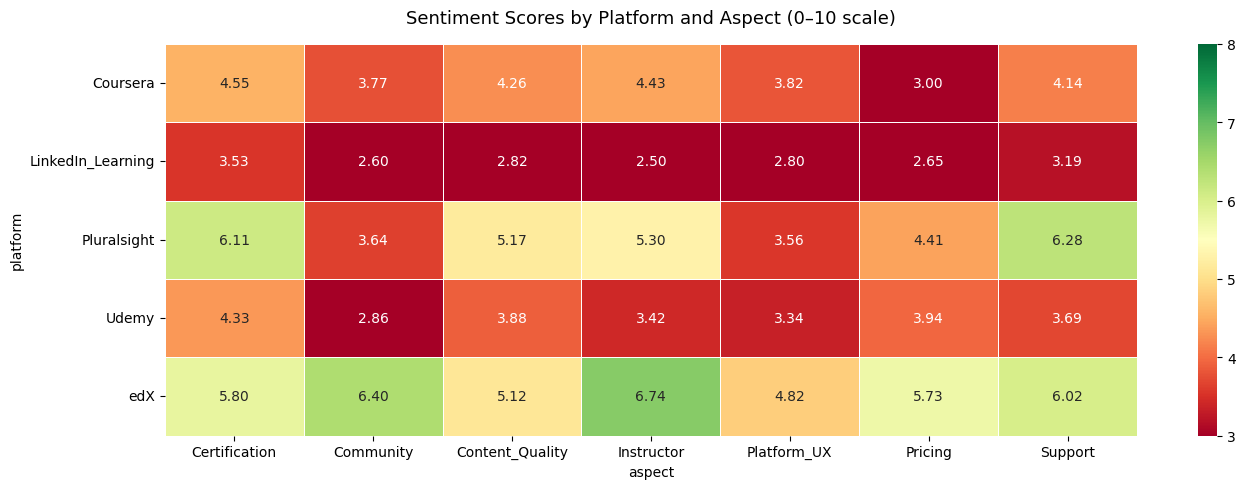

Heatmap saved!


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

pivot = pd.read_csv(f'{BASE}/data/processed/platform_scores.csv')
pivot = pivot.pivot(index='platform', columns='aspect', values='score')

plt.figure(figsize=(14, 5))
sns.heatmap(
    pivot,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    vmin=3, vmax=8,
    linewidths=0.5,
    linecolor='white'
)
plt.title('Sentiment Scores by Platform and Aspect (0–10 scale)',
          fontsize=13, pad=15)
plt.tight_layout()
plt.savefig(f'{BASE}/outputs/sentiment_heatmap.png', dpi=150)
plt.show()
print("Heatmap saved!")

In [1]:
# CELL 1 — Always run this first in NB03
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import os

BASE = '/content/drive/MyDrive/edtech_absa'
print("Ready. BASE =", BASE)

Mounted at /content/drive
Ready. BASE = /content/drive/MyDrive/edtech_absa


In [2]:
# CELL 5 — Platform scores pivot table

import pandas as pd
import numpy as np

df = pd.read_csv(f'{BASE}/data/processed/aspect_sentiments.csv')
print(f"Loaded {len(df)} scored sentences")

def weighted_avg(group):
    return np.average(group['sentiment_score'], weights=group['helpfulness_weight'])

platform_scores = (
    df.groupby(['platform', 'aspect'])
    .apply(weighted_avg, include_groups=False)
    .reset_index()
)
platform_scores.columns = ['platform', 'aspect', 'score']
platform_scores['score'] = platform_scores['score'].round(2)

review_counts = (
    df.groupby(['platform', 'aspect'])
    .size()
    .reset_index(name='review_count')
)

platform_scores = platform_scores.merge(review_counts, on=['platform', 'aspect'])

pivot = platform_scores.pivot(
    index='platform',
    columns='aspect',
    values='score'
).round(2)

print("=" * 60)
print("PLATFORM × ASPECT SENTIMENT SCORES (0–10)")
print("=" * 60)
print(pivot.to_string())

platform_scores.to_csv(f'{BASE}/data/processed/platform_scores.csv', index=False)
print("\nSaved platform_scores.csv!")

Loaded 35409 scored sentences
PLATFORM × ASPECT SENTIMENT SCORES (0–10)
aspect             Certification  Community  Content_Quality  Instructor  Platform_UX  Pricing  Support
platform                                                                                               
Coursera                    4.55       3.77             4.26        4.43         3.82     3.00     4.14
LinkedIn_Learning           3.53       2.60             2.82        2.50         2.80     2.65     3.19
Pluralsight                 6.11       3.64             5.17        5.30         3.56     4.41     6.28
Udemy                       4.33       2.86             3.88        3.42         3.34     3.94     3.69
edX                         5.80       6.40             5.12        6.74         4.82     5.73     6.02

Saved platform_scores.csv!
